<a href="https://colab.research.google.com/github/TonyVM/BarCodeGenerator/blob/master/ProjectEstocasticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Clustering Project

This project implements a graph-based approach to perform clustering on a binary image. The process involves treating the black pixels in the image as nodes in a graph and using a diffusion process to determine the similarity between these nodes.

## Project Steps:

1.  **Image Loading and Preprocessing:** Load a grayscale image and convert it to a binary image using thresholding. Identify the coordinates of all black pixels.
2.  **Graph Construction:** Consider each black pixel as a node in a graph. Calculate the Euclidean distances between all pairs of these nodes.
3.  **Weight Matrix Creation:** Construct a weight matrix where the weights represent the connections between nodes based on their distances. A weighting scheme is applied, and distances above a certain threshold are ignored.
4.  **Transition Matrix and P-visit Calculation:** Compute a transition matrix from the weight matrix, representing the probability of moving between nodes. A P-visit matrix is then calculated by raising the transition matrix to a power, indicating the probability of reaching one node from another within a specified number of steps.
5.  **Similarity Matrix Calculation and Optimization:** Calculate an initial similarity matrix based on the P-visit matrix. This matrix is then iteratively optimized to refine the similarity measures between nodes.
6.  **Clustering:** Threshold the final similarity matrix to identify strong connections. Use a propagation method to group connected nodes into clusters.
7.  **Visualization:** Visualize the identified clusters by coloring the pixels belonging to the largest clusters in the original image dimensions.

This approach aims to identify meaningful groupings of pixels within the image based on their spatial proximity and the calculated similarity measures.

---

# Proyecto de Agrupación de Imágenes (Clustering)

Este proyecto implementa un enfoque basado en grafos para realizar agrupamiento (clustering) en una imagen binaria. El proceso implica tratar los píxeles negros de la imagen como nodos en un grafo y utilizar un proceso de difusión para determinar la similitud entre estos nodos.

## Pasos del Proyecto:

1.  **Carga y Preprocesamiento de la Imagen:** Cargar una imagen en escala de grises y convertirla a una imagen binaria utilizando umbralización. Identificar las coordenadas de todos los píxeles negros.
2.  **Construcción del Grafo:** Considerar cada píxel negro como un nodo en un grafo. Calcular las distancias euclidianas entre todos los pares de estos nodos.
3.  **Creación de la Matriz de Pesos:** Construir una matriz de pesos donde los pesos representen las conexiones entre los nodos basándose en sus distancias. Se aplica un esquema de ponderación y se ignoran las distancias por encima de un cierto umbral.
4.  **Cálculo de la Matriz de Transición y P-visit:** Calcular una matriz de transición a partir de la matriz de pesos, representando la probabilidad de moverse entre nodos. Luego se calcula una matriz P-visit elevando la matriz de transición a una potencia, indicando la probabilidad de alcanzar un nodo desde otro dentro de un número específico de pasos.
5.  **Cálculo y Optimización de la Matriz de Similitud:** Calcular una matriz de similitud inicial basada en la matriz P-visit. Esta matriz se optimiza iterativamente para refinar las medidas de similitud entre los nodos.
6.  **Agrupamiento (Clustering):** Umbralizar la matriz de similitud final para identificar conexiones fuertes. Utilizar un método de propagación para agrupar los nodos conectados en clusters.
7.  **Visualización:** Visualizar los clusters identificados coloreando los píxeles que pertenecen a los clusters más grandes en las dimensiones originales de la imagen.

Este enfoque tiene como objetivo identificar agrupaciones significativas de píxeles dentro de la imagen basándose en su proximidad espacial y las medidas de similitud calculadas.

In [ ]:
import cv2
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import random

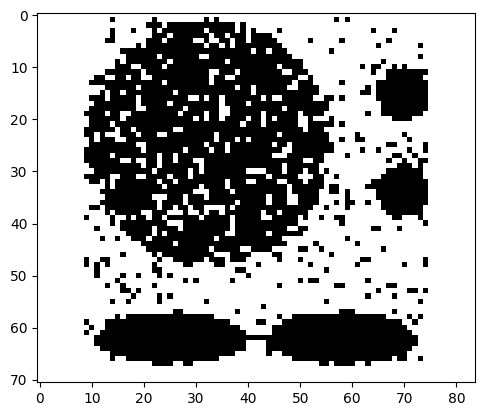

(71, 84)


In [ ]:
# Load the image file
img = cv2.imread('puntos4.png', cv2.IMREAD_GRAYSCALE) #imagen en escala de colores original

# imgGray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #ya la tenemos en escala de grises

umbral, bimage = cv2.threshold(img, 150, 255, cv2.THRESH_BINARY)

# bimage = cv2.resize(bimage, (int(bimage.shape[1] * 0.17),int(bimage.shape[0] * 0.17)))
matriz_bimg = np.array(bimage)

alto, ancho = bimage.shape

# Count the number of black pixels
black_pixels = np.sum(matriz_bimg == 0)

# Create a matrix MM with dimensions equal to the total number of black pixels
MM = np.zeros((black_pixels, black_pixels))

black_pixel_indices = np.where(matriz_bimg == 0)

plt.imshow(bimage, cmap='gray')
plt.show()
print(bimage.shape)

In [ ]:
coords = np.column_stack(black_pixel_indices) #ubico las coordenadas de los pixeles negros
print(f'Pixeles negros: {black_pixels}')
#calcular las distancias euclidianas entre puntos
dist_euclidianas = cdist(coords, coords)
print(f'Dimensiones distncias euclidianas: {dist_euclidianas.shape}')

Pixeles negros: 2297
Dimensiones distncias euclidianas: (2297, 2297)


In [ ]:
rows, cols = dist_euclidianas.shape
print(rows, cols)

2297 2297


In [ ]:
# W0 = np.zeros_like(dist_euclidianas, dtype=float)
dist_euclidianas[dist_euclidianas > np.sqrt(2)] = 0

def getMatrizPesos(rows, cols):
  w0 = np.zeros_like(dist_euclidianas, dtype=float)
  print(w0.shape)
  for i in range(rows):#rows
    current = dist_euclidianas[i]
    bigger_zero = current[current > 0]
    avg = np.mean(bigger_zero) #if bigger_zero.size > 0 else 0
    # print(f'{avg}')
    for j in range(cols):#cols
      if current[j] > 0:
        w0[i,j] = np.exp(-current[j]**2) / avg**2
        if w0[i,j] > np.sqrt(2):
          w0[i,j] = 0
  return w0

W0 = getMatrizPesos(rows, cols)

In [ ]:
print(W0)

[[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.27073399 0.        ]
 [0.         0.         0.         ... 0.25247253 0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [ ]:
print(W0.shape)

(2297, 2297)


In [ ]:
print(tabulate(W0[0:200], tablefmt='fancy'))

# Definir matriz de probabilidades

In [ ]:
def getMatrizP(mWeight):
  d_i = np.sum(mWeight, axis=1)
  matrizTrans = np.zeros_like(mWeight, dtype=float)
  mRow, mCol = mWeight.shape
  for i in range(mRow):
    for j in range(mCol):
      if d_i[i] != 0:
        matrizTrans[i, j] = mWeight[i, j] / d_i[i]
    # print('a')
  return matrizTrans

MTransition = getMatrizP(W0) #obtengo mi matriz de transitions

# **P-visit**

In [ ]:
def getPvisit(mtrans, exp):
  pVisit = np.zeros_like(mtrans)
  for i in range(1, (exp + 1)):
    pVisit = np.linalg.matrix_power(mtrans, i)
  return pVisit

power = 3
M3 = getPvisit(MTransition, power)

# Norma L, SimK, Similarity Matrix

In [ ]:
def getNormaL(X, Y):
    return np.sum(np.abs(X - Y))

In [ ]:
def getSimK(x, y, k):
  d = getNormaL(x, y)
  return np.exp(2 * k - d) - 1

In [ ]:
def getSimilarity(G, k):
  nodosQty = len(G)
  ws = np.zeros((nodosQty, nodosQty))
  for u in range(nodosQty):
    for v in range(nodosQty):
      ws[u,v] = getSimK(G[u], G[v], k)
  return ws

k = 3
matrizSimilarity = getSimilarity(M3, k)
mask = W0 == 0
matrizSimilarity[mask] = 0

# Optimizando

In [ ]:
def optimizeComputation(matrizSim, totalIter, k:int, mask):
  ms = matrizSim.copy() #aplico el metodo copy para evitar que mute la original
  for i in range(totalIter):
    mTransition = getMatrizP(ms)
    currentPv = getPvisit(mTransition, power)
    ms = getSimilarity(currentPv, k)
    ms[mask] = 0
  return mTransition, currentPv, ms

initMSimilarity = matrizSimilarity
totalIter = 7
MTransitionFinal, pvisitFinal, MSimilarityFinal = optimizeComputation(initMSimilarity, totalIter, k, mask)

In [ ]:
_umbral = 20
Mthresh = np.where((MSimilarityFinal > _umbral), 1, 0)

In [ ]:
#coord relaciones debiles
weakRelations = np.argwhere(Mthresh == 1)
weakRelationsMatrix = np.array(weakRelations)

linkWeakPix = np.unique(np.concatenate(weakRelationsMatrix))

In [ ]:
len(linkWeakPix)

2231

In [ ]:
pixelsWaste = coords[linkWeakPix,:]
bimage[pixelsWaste[:,0], pixelsWaste[:,1]] = 255

# Formar clusters

In [ ]:
MClusters = MSimilarityFinal
Mthresh = np.where(MClusters < _umbral, 0, 1) #localizando conexiones significativas

In [ ]:
def propagateClusters(mthresh):
  clusters = []
  totalPos = set(range(len(mthresh)))
  while totalPos:
    firstIndex = totalPos.pop()
    curCluster = np.array([firstIndex])
    while True:
      prevCluster = curCluster.copy() #evitar mutaciones
      newPos = np.unique(np.concatenate([np.where(mthresh[index] > 0)[0] for index in curCluster]))
      curCluster = np.unique(np.concatenate((curCluster, newPos)))
      if np.array_equal(prevCluster, curCluster):
        break
    clusters.append((firstIndex, curCluster))
    totalPos.difference_update(curCluster)
  return clusters

def getLargestClusters(clust, n):
  clusterPosSize = [(i, len(clust)) for i, (_, clust) in enumerate(clust)]
  clusterPosSize.sort(reverse= True, key= lambda c: c[1])
  largestC = [clust[i] for i, _ in clusterPosSize[:n]]
  selectedClust = [i for i,_ in clusterPosSize[:n]]
  return largestC, selectedClust

clusters = propagateClusters(Mthresh)


# Buscar clusters

In [ ]:
n = 3 # cantidad de clusters a buscar
largestC, selectedC = getLargestClusters(clusters, n)

for i, (firstIndex, ci) in enumerate(largestC):
  clusterSize = len(ci)
  clusterIndex = selectedC[i]
  print(f'Cluster {i+1}: Indice {clusterIndex}, primer pixel {firstIndex} - Size {clusterSize}')

NameError: name 'getLargestClusters' is not defined

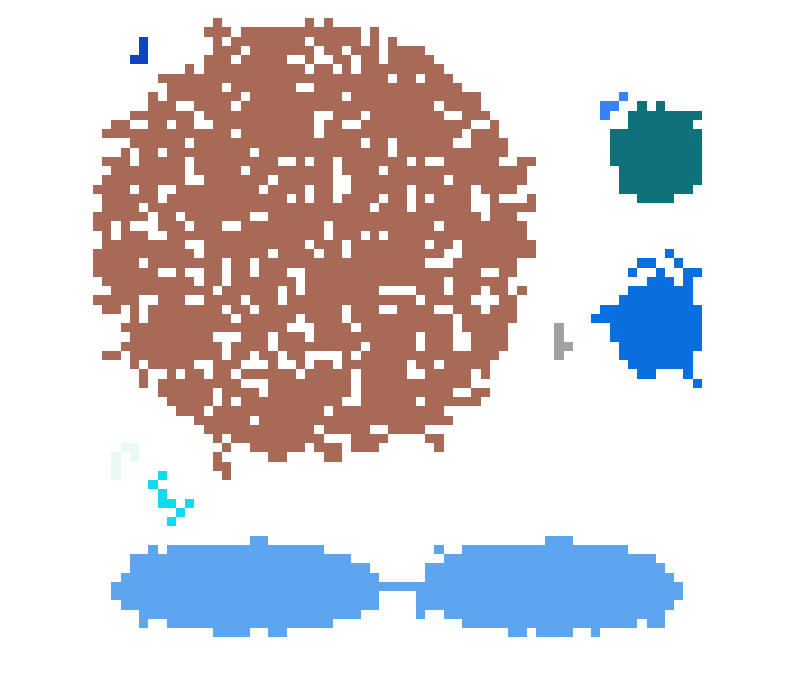

In [ ]:
bimage.shape

G_result = np.full((bimage.shape[0], bimage.shape[1], 3), 255, dtype=np.uint8)

coloresConjuntos = {}
c = largestC
for ci, _ in enumerate(c):
  color = tuple(random.randint(0, 255) for _ in range(3))
  coloresConjuntos[ci] = color

for ci, (initialIndex, indicesC) in enumerate(c):
  color = coloresConjuntos[ci]
  for ind in indicesC:
    row, col = coords[ind]
    G_result[row, col] = color

figure = plt.figure(figsize=(10, 10))
plt.imshow(G_result)
plt.axis('off')
plt.show()

In [ ]:
tupla = (1,2,3,4,5,1,3,4)
print(tupla)
tupla = (3,5,2,7)
print(tupla)

(1, 2, 3, 4, 5, 1, 3, 4)
(3, 5, 2, 7)


In [ ]:
import random
import numpy as np

numeros = np.arange(1, 21)
print(numeros)
dobles = [_ * 2 for _ in numeros]
print(dobles)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
[2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40]


In [ ]:
#!/bin/python3

import math
import os
import random
import re
import sys

#
# Complete the 'plusMinus' function below.
#
# The function accepts INTEGER_ARRAY arr as parameter.
#

def plusMinus(arr):
    n = len(arr)
    pos = sum(1 for e in arr if e > 0) / n
    neg = sum(1 for e in arr if e < 0) / n
    zeros = sum(1 for e in arr if e == 0) / n
    print(f'{pos:.6f}')
    print(f'{neg:.6f}')
    print(f'{zeros:.6f}')
    # Write your code here

if __name__ == '__main__':
    n = int(input().strip())

    arr = list(map(int, input().rstrip().split()))

    plusMinus(arr)


5
1 1 0 -1 -1
0.400000
0.400000
0.200000
